## 0. Project overview

**Project title**:
Reliable Brain-to-Communication: Motor Imagery Decoding for Simulated Accessible Typing

**Main question:**
Can motor imagery EEG be decoded reliably enough to support a simulated communication interface, and how do CSP+LDA and EEGNet compare in both accuracy and control usability?

## 1. Import

This section initializes all required libraries for EEG processing, machine learning, deep learning, and visualization.
- MNE is used for EEG data loading and preprocessing
- scikit-learn provides CSP and LDA for classical decoding
- PyTorch is used to implement EEGNet
- matplotlib is used for visualization and animation

In [3]:
# =========================
# 1. IMPORTS AND SETTINGS
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from mne.decoding import CSP

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.base import clone

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.patches import Rectangle

# the code here is to make plots a bit cleaner
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = False
np.random.seed(189)
torch.manual_seed(189)

DATA_DIR = Path("data")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## 2. Description

### Dataset and Task

This project uses **BCI Competition IV Dataset 2a**, a standard benchmark dataset for motor imagery brain-computer interfaces.

- **Subjects:** 9
- **Channels:** 22 EEG + 3 EOG
- **Sampling rate:** 250 Hz
- **Original classes:** left hand, right hand, feet, tongue
- **This project uses:** left vs right motor imagery only

The goal is to compare a classical EEG decoding pipeline (**CSP + LDA**) with a compact deep learning model (**EEGNet**) and then use model outputs to drive a simulated accessible typing interface.

In this project, I simplify the task to:
- Binary classification: left vs right hand imagery

This setup allows me to:
- Focus on a realistic control signal
- Directly map predictions to typing actions (move vs select)

## 3. Dataset setup and loading

This section standardizes and loads EEG data from .gdf files.

Main steps:
- Remove inconsistent channel naming (e.g., “EEG-” prefixes)
- Map channels to standard 10–20 system
- Separate EEG and EOG channels
- Apply a standard electrode montage

### 3.1 Expected data folder

In [4]:
DATA_DIR = Path("data")

### 3.2 Channel template for BCIC IV-2a

In [5]:
BCI2A_EEG_22 = [
    "Fz","FC3","FC1","FCz","FC2","FC4",
    "C5","C3","C1","Cz","C2","C4","C6",
    "CP3","CP1","CPz","CP2","CP4",
    "P1","Pz","P2","POz"
]

### 3.3 Loader function

This section standardizes the channel names and loads one .gdf file from BCI Competition IV Dataset 2a.

In [6]:
def load_bciciv2a_gdf(gdf_path):
    raw = mne.io.read_raw_gdf(gdf_path, preload=True, verbose=False)

    # Remove EEG- prefix to clean data
    raw.rename_channels({ch: ch.replace("EEG-", "") for ch in raw.ch_names})

    # Separate EEG-like and EOG-like channels
    eeg_like = [ch for ch in raw.ch_names if "EOG" not in ch.upper()]
    eog_like = [ch for ch in raw.ch_names if "EOG" in ch.upper()]

    # Rename first 22 EEG channels to standard names
    eeg_22 = eeg_like[:22]
    raw.rename_channels({old: new for old, new in zip(eeg_22, BCI2A_EEG_22)})

    # Set channel types
    ch_types = {ch: "eeg" for ch in BCI2A_EEG_22}
    for ch in eog_like:
        ch_types[ch] = "eog"
    raw.set_channel_types(ch_types)

    # Set montage
    montage = mne.channels.make_standard_montage("standard_1020")
    raw.set_montage(montage, on_missing="ignore")

    return raw

### 3.4 Load one demonstration file

In [7]:
raw = load_bciciv2a_gdf(DATA_DIR / "A01T.gdf")
print(raw.ch_names)

/opt/conda/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz', 'EOG-left', 'EOG-central', 'EOG-right']


## 4. Preprocessing

This section prepares the EEG signals for decoding

### 4.1 Bandpass filter

The data is filtered between 8–30 Hz, capturing:
- Mu rhythm (8–12 Hz)
- Beta rhythm (13–30 Hz)

These frequencies are known to reflect motor imagery.

In [8]:
raw.filter(8.0, 30.0, picks = "eeg", verbose = False)

<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>

### 4.2 Extract events

Event markers are extracted from annotations to identify trial timing

In [9]:
events, annot_event_id = mne.events_from_annotations(raw, verbose=False)
print("Annotation mapping:", annot_event_id)
print("Unique event values:", np.unique(events[:, 2]))

Annotation mapping: {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Unique event values: [ 1  2  3  4  5  6  7  8  9 10]


### 4.3 Class Selection

Only left (769) and right (770) motor imagery trials are kept. This simplifies the task into a binary control signal.

In [10]:
event_id = {
    "left": annot_event_id["769"],
    "right": annot_event_id["770"]
}
print("Using event_id:", event_id)

Using event_id: {'left': 7, 'right': 8}


### 4.4 Epoch the data

EEG signals are segmented into trials:
- Time window: 0–4 seconds

Each trial becomes one data sample. This converts continuous EEG into structured ML input.

In [11]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=0.0,
    tmax=4.0,
    baseline=None,
    picks="eeg",
    preload=True,
    verbose=False
)

print(epochs)
print("Left trials:", len(epochs["left"]))
print("Right trials:", len(epochs["right"]))

<Epochs | 144 events (all good), 0 – 4 s (baseline off), ~24.2 MiB, data loaded,
 'left': 72
 'right': 72>
Left trials: 72
Right trials: 72


## 5. Exploratory data analysis

This section verifies that the data contains meaningful patterns.

### 5.1 PSD plot

The PSD shows strong activity in the 8–30 Hz range, confirming that relevant motor imagery frequencies are present.

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


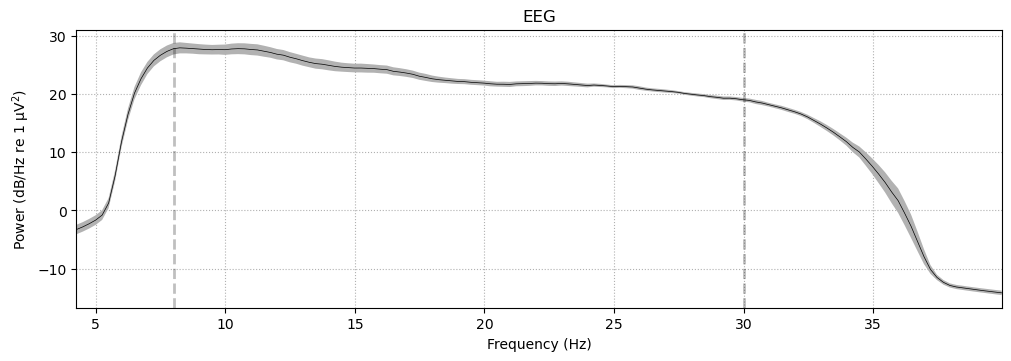

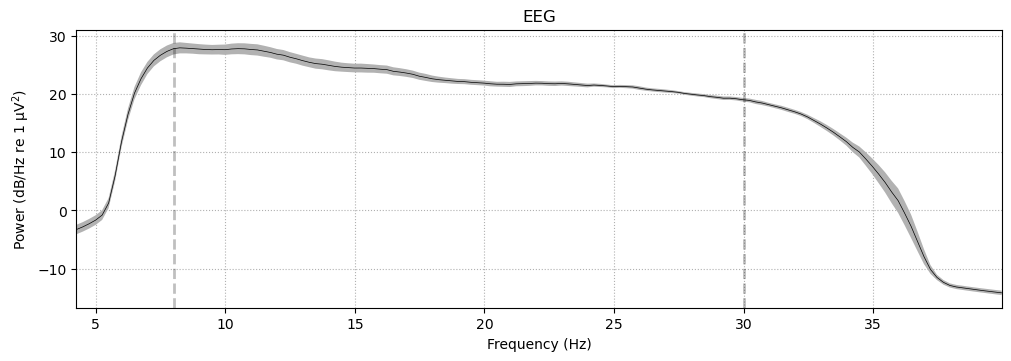

In [12]:
epochs.compute_psd(fmin=4, fmax=40).plot(average=True)

### 5.2 Average waveforms at C3/Cz/C4

These channels correspond to motor cortex areas.

Differences between left/right trials indicate:
- Lateralized brain activity
- Useful signals for classification

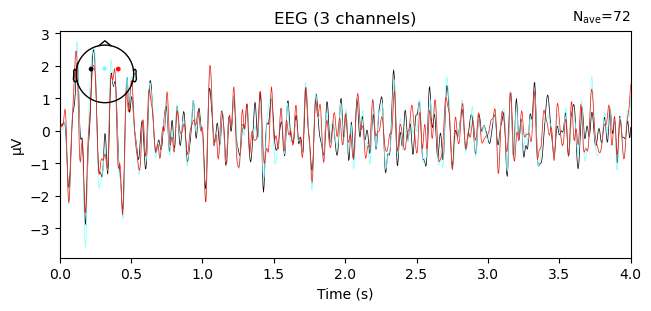

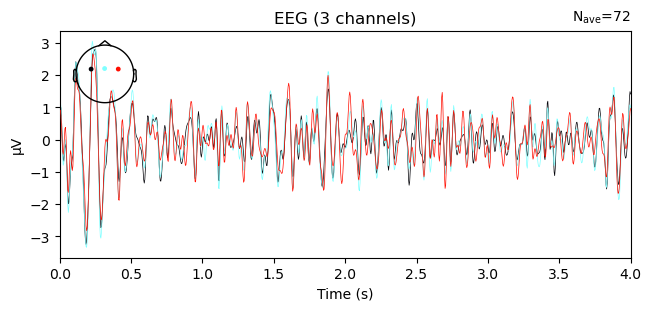

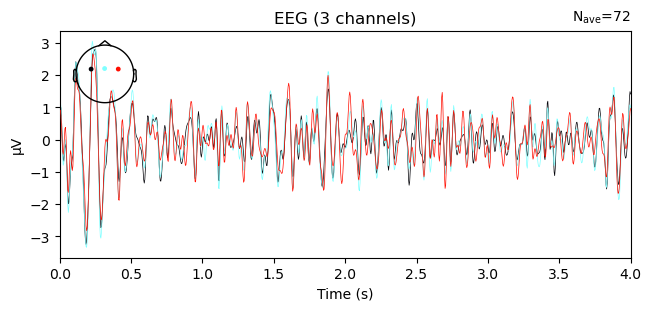

In [13]:
epochs["left"].average().plot(picks=["C3", "Cz", "C4"])
epochs["right"].average().plot(picks=["C3", "Cz", "C4"])

### 5.3 Mu-band power check

Quantitative comparison of mu-band power confirms:
- Slight differences between left and right imagery
- Signals are subtle but usable

This justifies using CSP and EEGNet.

In [14]:
epochs_mi = epochs.copy().crop(tmin=0.5, tmax=2.5)

psd = epochs_mi.compute_psd(method="welch", fmin=8, fmax=12, verbose=False)
psds = psd.get_data()
mu_power = psds.mean(axis=2)

n_left = len(epochs_mi["left"])
n_right = len(epochs_mi["right"])

ch_names = epochs_mi.ch_names
c3_idx = ch_names.index("C3")
c4_idx = ch_names.index("C4")

print("Left trials C3 mu:", mu_power[:n_left, c3_idx].mean())
print("Right trials C3 mu:", mu_power[n_left:, c3_idx].mean())
print("Left trials C4 mu:", mu_power[:n_left, c4_idx].mean())
print("Right trials C4 mu:", mu_power[n_left:, c4_idx].mean())

Left trials C3 mu: 1.7085513294303682e-12
Right trials C3 mu: 2.0269507540807324e-12
Left trials C4 mu: 2.0613927524717998e-12
Right trials C4 mu: 2.254298494813458e-12


## 6. Build ML dataset

EEG trials are converted into:
- X: shape (trials, channels, time)
- y: labels (0 = left, 1 = right)

This is the standard input format for:
- CSP (classical ML)
- EEGNet (deep learning)

In [15]:
X_left = epochs["left"].get_data()
X_right = epochs["right"].get_data()

X = np.concatenate([X_left, X_right], axis=0)
y = np.concatenate([
    np.zeros(len(X_left), dtype=int),
    np.ones(len(X_right), dtype=int)
])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (144, 22, 1001)
y shape: (144,)


## 7. Baseline model: CSP + LDA

### 7.1 Cross-validation accuracy

CSP extracts spatial features, and LDA performs classification.

Result:
- ~81% accuracy (mean)

This is strong performance for motor imagery EEG.

In [16]:
pipe_csp = Pipeline([
    ("csp", CSP(n_components=6, log=True, norm_trace=False)),
    ("lda", LDA())
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=189)
scores_csp = []

for tr, va in cv.split(X, y):
    model = clone(pipe_csp)
    model.fit(X[tr], y[tr])
    pred = model.predict(X[va])
    scores_csp.append((pred == y[va]).mean())

scores_csp = np.array(scores_csp)
print("CSP+LDA scores:", scores_csp)
print("CSP+LDA mean ± std:", scores_csp.mean(), "±", scores_csp.std())

Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMP

### 7.2 Confusion matrix

The model shows:
- Balanced performance
- Slight confusion between classes

Indicates reliable but imperfect control signals.

Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMP

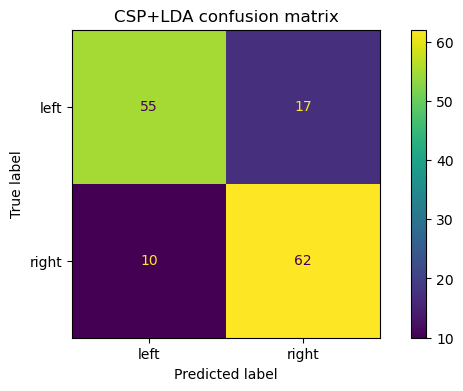

In [17]:
y_true_all = []
y_pred_all = []

for tr, va in cv.split(X, y):
    model = clone(pipe_csp)
    model.fit(X[tr], y[tr])
    pred = model.predict(X[va])
    y_true_all.append(y[va])
    y_pred_all.append(pred)

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

cm = confusion_matrix(y_true_all, y_pred_all)
disp = ConfusionMatrixDisplay(cm, display_labels=["left", "right"])
disp.plot(values_format="d")
plt.title("CSP+LDA confusion matrix")
plt.show()

### 7.3 CSP spatial patterns

CSP identifies brain regions most relevant for classification.

These patterns align with motor cortex areas:
- C3 (left hand)
- C4 (right hand)

This confirms the model is physiologically meaningful, not random.

Computing rank from data with rank=None
    Using tolerance 4e-05 (2.2e-16 eps * 22 dim * 8.2e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
NOTE: plot_patterns() is a legacy function. New code should use get_spatial_filter_from_estimator(clf, info=info).plot_patterns().


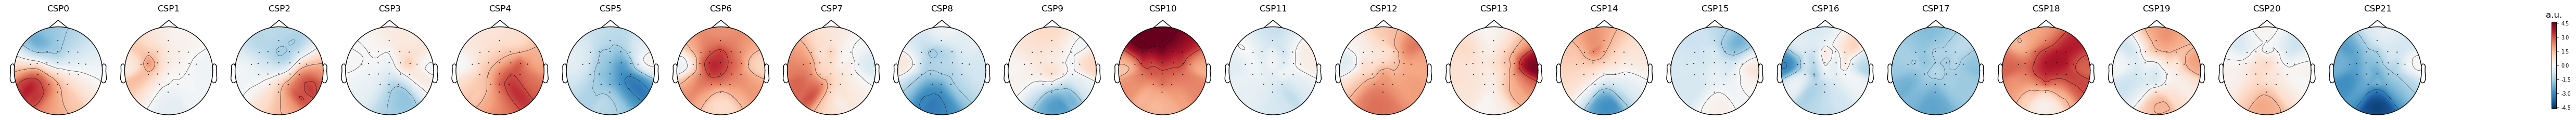

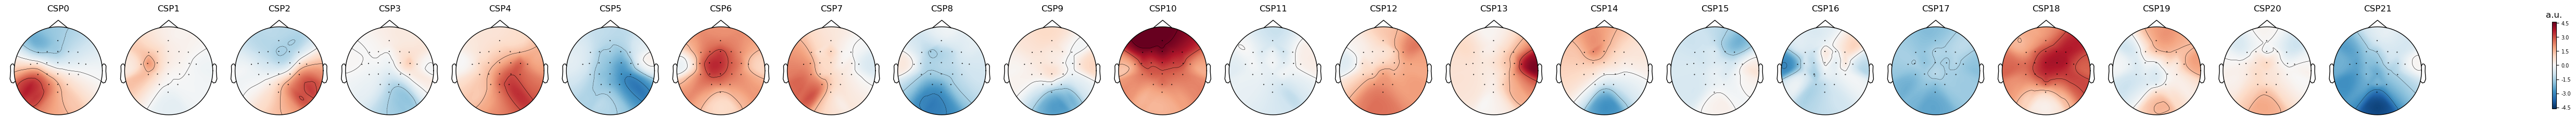

In [18]:
pipe_csp.fit(X, y)
pipe_csp.named_steps["csp"].plot_patterns(epochs.info, ch_type="eeg", units="a.u.", size=1.5)

## 8. EEGNet model

### 8.1 Define EEGNet

EEGNet is a compact CNN designed specifically for EEG.

Key components:
- Temporal convolution (frequency features)
- Depthwise convolution (spatial filtering)
- Separable convolution (efficient feature learning)

This mimics CSP but in a learned, data-driven way.


In [19]:
class EEGNet(nn.Module):
    def __init__(self, n_chans, n_times, n_classes=2, F1=8, D=2, kernel_len=64, dropout=0.25):
        super().__init__()
        F2 = F1 * D

        self.conv1 = nn.Conv2d(1, F1, (1, kernel_len), padding=(0, kernel_len // 2), bias=False)
        self.bn1 = nn.BatchNorm2d(F1)

        self.depthwise = nn.Conv2d(F1, F2, (n_chans, 1), groups=F1, bias=False)
        self.bn2 = nn.BatchNorm2d(F2)

        self.pool1 = nn.AvgPool2d((1, 4))
        self.drop1 = nn.Dropout(dropout)

        self.sep_depth = nn.Conv2d(F2, F2, (1, 16), padding=(0, 8), groups=F2, bias=False)
        self.sep_point = nn.Conv2d(F2, F2, (1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(F2)

        self.pool2 = nn.AvgPool2d((1, 8))
        self.drop2 = nn.Dropout(dropout)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_chans, n_times)
            feat_dim = self._features(dummy).shape[1]

        self.fc = nn.Linear(feat_dim, n_classes)

    def _features(self, x):
        x = F.elu(self.bn1(self.conv1(x)))
        x = F.elu(self.bn2(self.depthwise(x)))
        x = self.drop1(self.pool1(x))
        x = F.elu(self.bn3(self.sep_point(self.sep_depth(x))))
        x = self.drop2(self.pool2(x))
        return x.flatten(start_dim=1)

    def forward(self, x):
        return self.fc(self._features(x))

### 8.2 Training helper

The model is trained using:
- Adam optimizer
- Cross-entropy loss
- Mini-batch learning

In [20]:
def train_eegnet(model, train_loader, val_loader, device="cpu", epochs=30, lr=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    losses = []

    for _ in range(epochs):
        model.train()
        running_loss = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(yb)
            total += len(yb)

        losses.append(running_loss / total)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb).argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += len(yb)

    return np.array(losses), correct / total

### 8.3 Prepare tensors

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y, dtype=torch.long)

### 8.4 5-fold CV

Result:
-  ~61% accuracy

Lower than CSP + LDA.

In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=189)
scores_eegnet = []
example_losses = None

for fold, (tr, va) in enumerate(cv.split(X, y), 1):
    train_loader = DataLoader(TensorDataset(X_tensor[tr], y_tensor[tr]), batch_size=16, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_tensor[va], y_tensor[va]), batch_size=64, shuffle=False)

    model = EEGNet(n_chans=X.shape[1], n_times=X.shape[2], n_classes=2)
    losses, acc = train_eegnet(model, train_loader, val_loader, device=device, epochs=30, lr=1e-3)

    if example_losses is None:
        example_losses = losses

    scores_eegnet.append(acc)
    print(f"Fold {fold}: {acc:.3f}")

scores_eegnet = np.array(scores_eegnet)
print("EEGNet mean ± std:", scores_eegnet.mean(), "±", scores_eegnet.std())

Fold 1: 0.517
Fold 2: 0.517
Fold 3: 0.655
Fold 4: 0.586
Fold 5: 0.821
EEGNet mean ± std: 0.6194581280788178 ± 0.11319871204800898


### 8.5 Loss curve

Loss decreases steadily → model is learning.

BUT:
- Likely underfitting / insufficient data

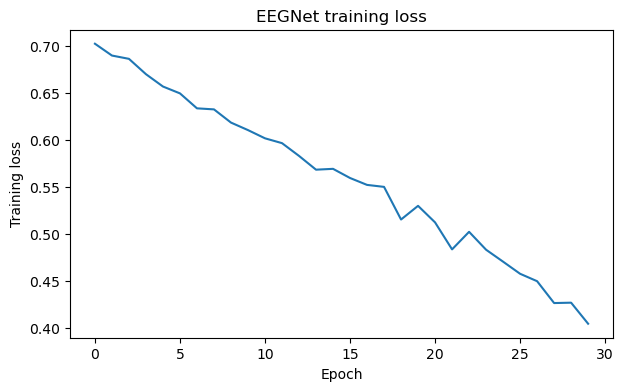

In [23]:
plt.figure(figsize=(7, 4))
plt.plot(example_losses)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("EEGNet training loss")
plt.show()

## 9. Saliency / interpretability

This section explains what EEGNet is focusing on.

### 9.1 Saliency function

Shows:
- Which channels and time points influence predictions

Strong activation near motor cortex channels (C3, C4). This confirms:
- Model is learning meaningful brain patterns

In [24]:
def saliency_map(model, x, target_class=None):
    model.eval()
    x = x.clone().detach().requires_grad_(True)
    logits = model(x)

    if target_class is None:
        target_class = logits.argmax(dim=1).item()

    logits[0, target_class].backward()
    sal = x.grad.detach().abs()[0, 0].cpu().numpy()
    return sal, target_class

### 9.2 Train final model on all data

In [25]:
full_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=16, shuffle=True)
model = EEGNet(n_chans=X.shape[1], n_times=X.shape[2], n_classes=2).to(device)
_ = train_eegnet(model, full_loader, full_loader, device=device, epochs=30, lr=1e-3)

### 9.3 Plot saliency

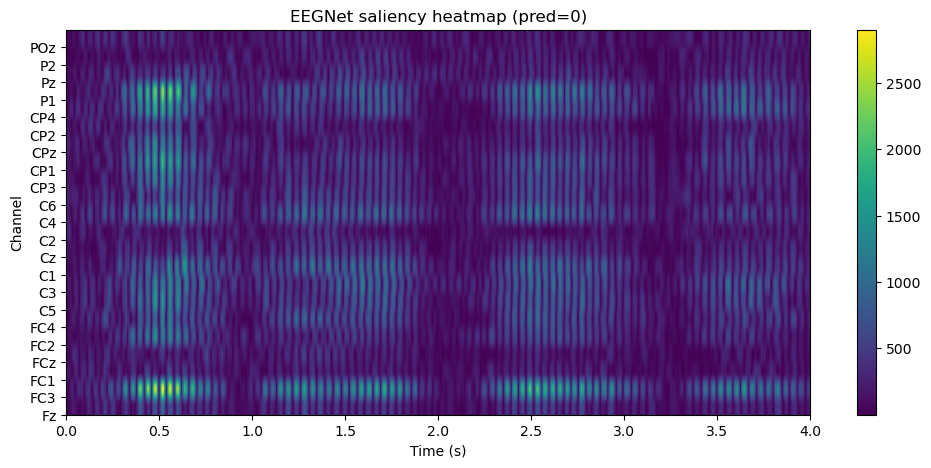

In [26]:
idx = 0
sal, pred = saliency_map(model, X_tensor[idx:idx+1].to(device))

plt.figure(figsize=(12, 5))
plt.imshow(
    sal,
    aspect="auto",
    origin="lower",
    extent=[epochs.times[0], epochs.times[-1], 0, len(epochs.ch_names)]
)
plt.yticks(np.arange(len(epochs.ch_names)), epochs.ch_names)
plt.xlabel("Time (s)")
plt.ylabel("Channel")
plt.title(f"EEGNet saliency heatmap (pred={pred})")
plt.colorbar()
plt.show()

## 10. Simulated typing interface

Instead of only evaluating accuracy, I simulate real use.

Control mapping:
- Class 0 → move cursor
- Class 1 → select key

Three control strategies:
- 1.	Raw (no filtering)
- 2.	Confidence-aware (threshold)
- 3.	Smoothed (temporal averaging)

This converts ML outputs into human interaction.

### 10.1 Train a probability model for typing

Use CSP+LDA first because predict_proba is simple.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=189, stratify=y
)

typing_model = Pipeline([
    ("csp", CSP(n_components=6, log=True, norm_trace=False)),
    ("lda", LDA())
])

typing_model.fit(X_train, y_train)

print("Train accuracy:", typing_model.score(X_train, y_train))
print("Test accuracy:", typing_model.score(X_test, y_test))

Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 22 dim * 6.9e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Train accuracy: 0.89
Test accuracy: 0.8409090909090909


### 10.2 Keyboard definition

In [28]:
keyboard = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ") + ["_", "<"]
# "_" = space
# "<" = backspace

### 10.3 Display helper

In [29]:
def display_keyboard_state(keyboard, cursor_idx, typed_text):
    display_row = []
    for i, key in enumerate(keyboard):
        if i == cursor_idx:
            display_row.append(f"[{key}]")
        else:
            display_row.append(f" {key} ")
    print(" ".join(display_row))
    print("Typed:", typed_text)
    print("-" * 80)

### 10.4 Prediction with confidence

In [30]:
def predict_with_confidence(model, x_trial):
    x_trial = x_trial[np.newaxis, ...]
    probs = model.predict_proba(x_trial)[0]
    pred = np.argmax(probs)
    conf = np.max(probs)
    return pred, conf, probs

### 10.5 Action function

In [31]:
def apply_action(pred_label, cursor_idx, typed_text, keyboard):
    if pred_label == 0:  # move
        cursor_idx = (cursor_idx + 1) % len(keyboard)
    elif pred_label == 1:  # select
        selected = keyboard[cursor_idx]
        if selected == "_":
            typed_text += " "
        elif selected == "<":
            typed_text = typed_text[:-1]
        else:
            typed_text += selected
    return cursor_idx, typed_text

### 10.6 Raw typing simulation

In [32]:
def simulate_typing(model, X_trials, keyboard, threshold=0.75, max_steps=20):
    cursor_idx = 0
    typed_text = ""
    history = []

    for step in range(min(max_steps, len(X_trials))):
        pred, conf, probs = predict_with_confidence(model, X_trials[step])

        acted = False
        if conf >= threshold:
            cursor_idx, typed_text = apply_action(pred, cursor_idx, typed_text, keyboard)
            acted = True

        history.append({
            "step": step,
            "pred": pred,
            "conf": conf,
            "probs": probs,
            "acted": acted,
            "cursor_idx": cursor_idx,
            "typed_text": typed_text
        })

    return history

### 10.7 Smoothed typing simulation

In [33]:
def simulate_typing_smoothed(model, X_trials, keyboard, threshold=0.75, window=3, max_steps=20):
    cursor_idx = 0
    typed_text = ""
    prob_buffer = []
    history = []

    for step in range(min(max_steps, len(X_trials))):
        pred, conf, probs = predict_with_confidence(model, X_trials[step])
        prob_buffer.append(probs)

        if len(prob_buffer) > window:
            prob_buffer.pop(0)

        avg_probs = np.mean(prob_buffer, axis=0)
        smooth_pred = np.argmax(avg_probs)
        smooth_conf = np.max(avg_probs)

        acted = False
        if smooth_conf >= threshold:
            cursor_idx, typed_text = apply_action(smooth_pred, cursor_idx, typed_text, keyboard)
            acted = True

        history.append({
            "step": step,
            "raw_pred": pred,
            "raw_conf": conf,
            "smooth_pred": smooth_pred,
            "smooth_conf": smooth_conf,
            "acted": acted,
            "cursor_idx": cursor_idx,
            "typed_text": typed_text
        })

    return history

history_raw = simulate_typing(typing_model, X_test, keyboard, threshold=0.0, max_steps=15)
history_conf = simulate_typing(typing_model, X_test, keyboard, threshold=0.75, max_steps=15)
history_smooth = simulate_typing_smoothed(typing_model, X_test, keyboard, threshold=0.75, window=3, max_steps=15)

## 11. Typing usability metrics

Evaluate usability using:
- Number of actions
- Final typed text
- Edit distance to target
- Character accuracy

### 11.1 Edit distance

In [34]:
def levenshtein(a, b):
    dp = [[0]*(len(b)+1) for _ in range(len(a)+1)]
    for i in range(len(a)+1):
        dp[i][0] = i
    for j in range(len(b)+1):
        dp[0][j] = j
    for i in range(1, len(a)+1):
        for j in range(1, len(b)+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + cost
            )
    return dp[-1][-1]

### 11.2 Metrics function

In [47]:
def typing_metrics(history, target_word=None):
    if len(history) == 0:
        return {}

    final_text = history[-1]["typed_text"]
    num_steps = len(history)
    num_actions = sum(h["acted"] for h in history)

    metrics = {
        "final_text": final_text,
        "num_steps": num_steps,
        "num_actions": num_actions,
        "text_length": len(final_text),
        "actions_per_step": num_actions / num_steps if num_steps > 0 else 0
    }

    if target_word is not None:
        dist = levenshtein(final_text, target_word)
        metrics["target_word"] = target_word
        metrics["edit_distance"] = dist
        metrics["exact_match"] = (final_text == target_word)
        metrics["char_accuracy_like"] = 1 / (1 + dist)

    return metrics

### 11.3 Run three modes

In [48]:
target_word = "HELLO"

metrics_raw = typing_metrics(history_raw, target_word=target_word)
metrics_conf = typing_metrics(history_conf, target_word=target_word)
metrics_smooth = typing_metrics(history_smooth, target_word=target_word)

print("Raw:", metrics_raw)
print("Confidence-aware:", metrics_conf)
print("Smoothed:", metrics_smooth)

Raw: {'final_text': 'AABBBBCFF', 'num_steps': 15, 'num_actions': 15, 'text_length': 9, 'actions_per_step': 1.0, 'target_word': 'HELLO', 'edit_distance': 9, 'exact_match': False, 'char_accuracy_like': 0.1}
Confidence-aware: {'final_text': 'ABBBBCF', 'num_steps': 15, 'num_actions': 13, 'text_length': 7, 'actions_per_step': 0.8666666666666667, 'target_word': 'HELLO', 'edit_distance': 7, 'exact_match': False, 'char_accuracy_like': 0.125}
Smoothed: {'final_text': 'AAAA', 'num_steps': 15, 'num_actions': 5, 'text_length': 4, 'actions_per_step': 0.3333333333333333, 'target_word': 'HELLO', 'edit_distance': 5, 'exact_match': False, 'char_accuracy_like': 0.16666666666666666}


## 12. Usability comparison plot

In [49]:
summary_df = pd.DataFrame([
    {
        "Mode": "Raw",
        "Actions": metrics_raw["num_actions"],
        "EditDistance": metrics_raw["edit_distance"],
        "CharScore": metrics_raw["char_accuracy_like"],
    },
    {
        "Mode": "Confidence",
        "Actions": metrics_conf["num_actions"],
        "EditDistance": metrics_conf["edit_distance"],
        "CharScore": metrics_conf["char_accuracy_like"],
    },
    {
        "Mode": "Smoothed",
        "Actions": metrics_smooth["num_actions"],
        "EditDistance": metrics_smooth["edit_distance"],
        "CharScore": metrics_smooth["char_accuracy_like"],
    }
])

print(summary_df)

summary_df["CharScore"] = pd.to_numeric(summary_df["CharScore"], errors="coerce")
summary_df["Actions"] = pd.to_numeric(summary_df["Actions"], errors="coerce")
summary_df["EditDistance"] = pd.to_numeric(summary_df["EditDistance"], errors="coerce")

         Mode  Actions  EditDistance  CharScore
0         Raw       15             9   0.100000
1  Confidence       13             7   0.125000
2    Smoothed        5             5   0.166667


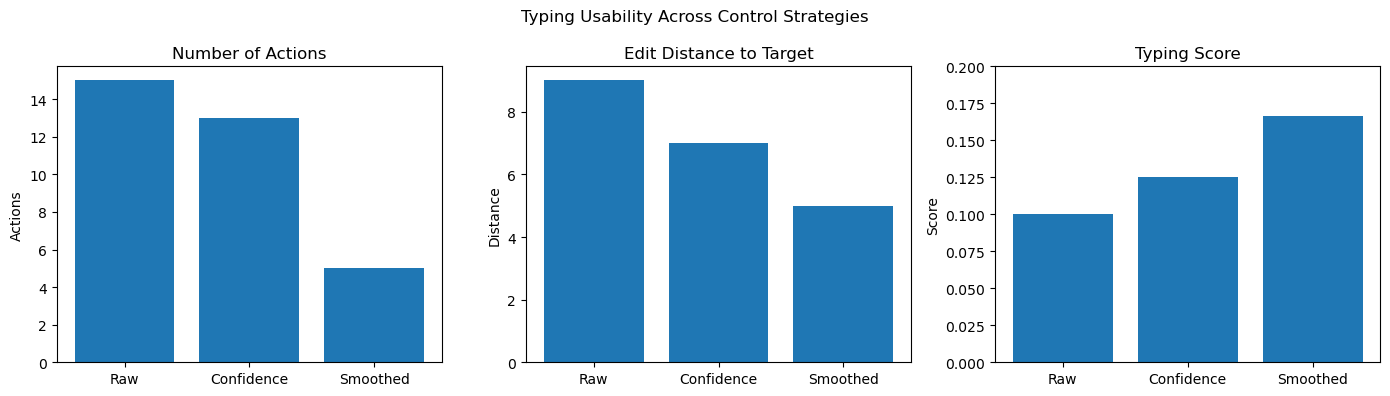

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(summary_df["Mode"], summary_df["Actions"])
axes[0].set_title("Number of Actions")
axes[0].set_ylabel("Actions")

axes[1].bar(summary_df["Mode"], summary_df["EditDistance"])
axes[1].set_title("Edit Distance to Target")
axes[1].set_ylabel("Distance")

axes[2].bar(summary_df["Mode"], summary_df["CharScore"])
axes[2].set_title("Typing Score")
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 0.2)

plt.suptitle("Typing Usability Across Control Strategies")
plt.tight_layout()
plt.show()

## 13. Animated typing UI

The visualization shows:
- Cursor movement
- Predictions
- Confidence
- Typed output over time
    
### 13.1 Animation function

In [ ]:
def animate_typing_ui(history, keyboard, threshold=0.75, title="Simulated BCI Typing"):
    fig, ax = plt.subplots(figsize=(16, 5))

    def update(frame):
        ax.clear()
        ax.axis("off")

        state = history[frame]
        cursor_idx = state["cursor_idx"]
        typed_text = state["typed_text"]
        conf = state.get("smooth_conf", state.get("conf", 0.0))
        pred = state.get("smooth_pred", state.get("pred", -1))
        acted = state["acted"]

        for i, key in enumerate(keyboard):
            face = "lightblue" if i == cursor_idx else "white"
            ax.text(i, 0, key, fontsize=14, ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.35", facecolor=face, edgecolor="black"))

        ax.text(len(keyboard)/2, -1.2, f"Typed: {typed_text}", fontsize=18, ha="center")

        pred_str = "LEFT / MOVE" if pred == 0 else "RIGHT / SELECT"
        ax.text(len(keyboard)/2, 1.4,
                f"Step {frame+1} | Prediction: {pred_str} | Confidence: {conf:.2f} | Acted: {acted}",
                fontsize=12, ha="center")

        bar_x = len(keyboard) * 0.25
        bar_w = len(keyboard) * 0.5
        ax.add_patch(Rectangle((bar_x, 0.9), bar_w, 0.18, fill=False, edgecolor="black"))
        ax.add_patch(Rectangle((bar_x, 0.9), bar_w * conf, 0.18,
                               color="green" if conf >= threshold else "orange"))
        ax.text(bar_x + bar_w/2, 1.15, f"Confidence Threshold = {threshold:.2f}",
                ha="center", fontsize=10)

        ax.set_xlim(-1, len(keyboard))
        ax.set_ylim(-2, 2)
        ax.set_title(title, fontsize=16)

    ani = FuncAnimation(fig, update, frames=len(history), interval=900, repeat=False)
    plt.close(fig)   # prevents empty static figure
    return ani

### 13.2 Run animations

In [ ]:
ani_raw = animate_typing_ui(history_raw, keyboard, threshold=0.0, title="Raw Control")
HTML(ani_raw.to_jshtml())

ani_conf = animate_typing_ui(history_conf, keyboard, threshold=0.75, title="Confidence-Aware Control")
HTML(ani_conf.to_jshtml())

ani_smooth = animate_typing_ui(history_smooth, keyboard, threshold=0.75, title="Smoothed Control")
HTML(ani_smooth.to_jshtml())

ani_raw.save("raw_control.gif", writer="pillow", fps=1)
ani_conf.save("confidence_control.gif", writer="pillow", fps=1)
ani_smooth.save("smoothed_control.gif", writer="pillow", fps=1)

In [ ]:
from IPython.display import Image
Image(filename="smoothed_control.gif")

print(len(history_raw))
print(len(history_conf))
print(len(history_smooth))
history_smooth[0]

## 14. Saliency + decision overlay

Combines:
- Model attention (saliency)
- Actual decision (typing action)

This connects: brain signal → model → user action

In [ ]:
def plot_saliency_with_decision(sal, epochs, state, title="Saliency + Typing Decision"):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [3, 1]})

    ax = axes[0]
    im = ax.imshow(
        sal,
        aspect="auto",
        origin="lower",
        extent=[epochs.times[0], epochs.times[-1], 0, len(epochs.ch_names)]
    )
    ax.set_yticks(np.arange(len(epochs.ch_names)))
    ax.set_yticklabels(epochs.ch_names)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Channel")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.02)

    for motor_ch in ["C3", "Cz", "C4"]:
        if motor_ch in epochs.ch_names:
            yline = epochs.ch_names.index(motor_ch)
            ax.axhline(yline, color="white", linestyle="--", linewidth=0.8)

    ax2 = axes[1]
    ax2.axis("off")
    pred = state.get("smooth_pred", state.get("pred"))
    conf = state.get("smooth_conf", state.get("conf"))
    acted = state["acted"]
    typed_text = state["typed_text"]

    pred_str = "LEFT / MOVE" if pred == 0 else "RIGHT / SELECT"
    info = (
        f"Prediction: {pred_str}\n"
        f"Confidence: {conf:.3f}\n"
        f"Acted: {acted}\n"
        f"Typed text: {typed_text}"
    )
    ax2.text(0.02, 0.5, info, fontsize=13, va="center")

    plt.tight_layout()
    plt.show()

In [ ]:
idx = 0
sal, pred = saliency_map(model, X_tensor[idx:idx+1].to(device))
plot_saliency_with_decision(sal, epochs, history_smooth[idx], title="EEGNet Saliency During Typing")

## 15. Conclusion

This project shows that I can use EEG signals from motor imagery to control a simple BCI system, but it also shows that accuracy alone is not enough.

The CSP + LDA model performed better than EEGNet, reaching about 81% accuracy. This likely happens because our dataset is not very large. CSP is designed for small EEG datasets and works well at extracting useful spatial patterns. EEGNet, on the other hand, usually needs more data to learn effectively, so its performance is lower here. More importantly, when I moved from classification to actual control (typing simulation), I saw a new problem. Even if the model is accurate, the output can still be unstable. The raw predictions caused too many unwanted actions. When we added confidence thresholds and smoothing, the system became much easier to control. This shows that building a BCI is not just about getting high accuracy. I also need to think about how the predictions behave over time and how the user interacts with the system.

There are still some limitations. We only used a small dataset and a simple left vs right task. Also, everything was done offline, so real-time performance may be different. In the future, I can improve this system by testing it in real time, adapting it to each user, and improving the deep learning model with more data. Overall, this project shows that a good BCI system needs both good models and stable control behavior.
